In [43]:
from numpy import array, zeros, where, arange, linspace, exp, sin, cos, sort, sum, dot
from numpy.random import uniform, choice, seed
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

In [44]:
sigmoid = lambda x: 1 / (1 + exp(-x))
seed(42)

def f(x,y, lump = (1,1)):
    return (sin(x/2) + sigmoid(x - 3)*2 + 5 + sin(x/4)) * 2 * exp(-.01*((x-lump[0])**2 + (y-lump[1])**2))

In [49]:
num_samples = 10000

x = list(uniform(-20, 20, num_samples))
y = list(uniform(-20, 20, num_samples))

z = [f(i,j) for i,j in zip(x,y)]

In [50]:
df = pd.DataFrame({'x': x, 'y': y, 'z': z})
df.head()

,x,y,z
0,-9.531773,6.172253,2.680904
1,-10.120848,-16.798697,0.131148
2,16.250183,-10.306808,0.390064
3,-10.018152,10.947174,1.184036
4,-9.122011,1.147434,3.753895


In [73]:
def plot_points(x, y, z, view_angle=-60, elevation=30):
    ax = plt.axes(projection='3d')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.azim = view_angle
    ax.elev = elevation
    ax.scatter(x, y, z, c=z, cmap='viridis', linewidth=0.5);

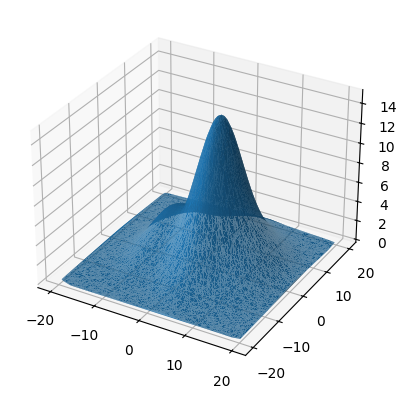

In [74]:
ax = plt.axes(projection='3d')
ax.plot_trisurf(x, y, z, linewidth=0.2, antialiased=True);

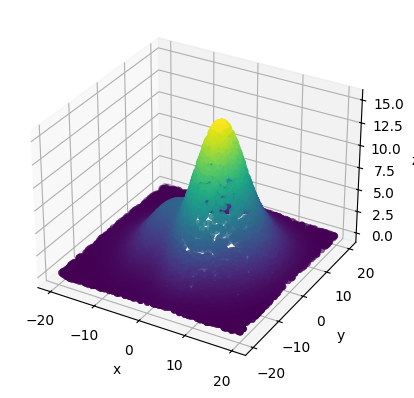

In [75]:
plot_points(x, y, z)

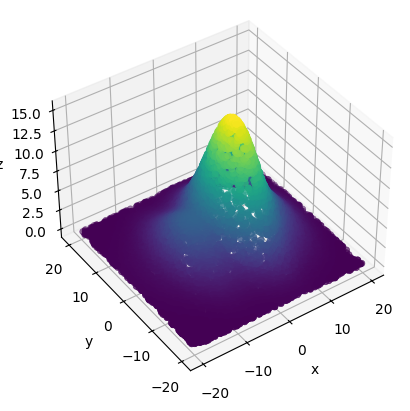

In [82]:
plot_points(x, y, z, -125, 40)

## Lets Build a Neural Network :)

Lets describe the equations! $\beta$ and $w$ are weights (bias and scalar respectively), $X = \{x_1, x_2, \ldots, x_p\}$ are the data for $p$ neurons in the previous layer, $A_{l,k}$ is the $k$th neuron in the $l$th hidden layer, $A_j$ is the value of the jth neuron of the previous layer, $g(z)$ is the activation function, $f(x)$ is the output, and $N$ is the number of data points.
$$A_{l,k}(x) = g(\beta_{l,k} + \sum_{j=1}^pw_{l,k,j}A_j)$$

$f(x)$ is the same but with an extra bias term and sometimes without an activation function:
$$f_k(x) = \alpha_{final,k} + g(\beta_{l,k} + \sum_{j=1}^pw_{l,k,j}A_j)$$
$$f_k(x) = \beta_{l,k} + \sum_{j=1}^pw_{l,k,j}A_j$$

These functions describe the model but not how to *train* the model. Do do so, we need a loss function and backpropagation. We will be using L2 loss:
$$R(\theta) = \frac{1}{N}\sum^N_{i=1}(y - f_\theta(X_i))^2$$
$$\frac{\partial R}{\partial \theta_i} =  -2\sum^N_{i=1}(y - f_\theta(X_i))*\frac{\partial f_\theta(X_i)}{\partial \theta_i}$$
$$\frac{\partial f_\theta(X_i)}{\partial \theta_i} = \frac{\partial}{\partial \theta_i} (\alpha_{final,k} + g(\beta_{l,k} + \sum_{j=1}^pw_{l,k,j}A_j))$$

Backpropagation is simpler to compute the closer $\theta_i$ is to the output layer. The reason is that there are more functions that 

**Idea!! skipping optimizing along weights in earlier hidden layers could speed up time since they're more computationally intensive to compute**

In [87]:
def f(x,y,z):
    return x**2 - y**2 + z**(1/2)

x = 0
y = 5
z = 5

delta = 0.000001

f(x,y,z), (f(x,y,z) - f(x + delta, y, z)) / delta

(-22.76393202250021, -9.983125437429408e-07)